In [1]:

# ██╗██╗███╗   ██╗████████╗
# ██║██║████╗  ██║╚══██╔══╝
# ██║██║██╔██╗ ██║   ██║
# ██║██║██║╚██╗██║   ██║
# ██║██║██║ ╚████║   ██║
# ╚═╝╚═╝╚═╝  ╚═══╝   ╚═╝
# @Time    : 2022-05-12 20:44:37.000-05:00
# @Author  : 𝕫𝕙𝕒𝕠𝕤𝕙𝕖𝕟𝕘
# @email   : zhaosheng@nuaa.edu.cn
# @Blog    : http://iint.icu/
# @File    : /home/zhaosheng/paper4/ipynb/check_results.py
# @Describe: check 4d ct results

import torch
import ants
import os
import numpy as np
from utils.ddf_tools import warp_img_npy,warp_img_nii
from utils.lung import get_lung_mask
from utils.plot import plot_ct
import os
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt

logging.basicConfig(filename='./check_results.log', format="%(levelname)s %(asctime)s - %(message)s", level=logging.INFO)

def get_result(ddf_real,ddf_fake,moving,fixed,t_index,savepath=None,plot=True,get_lung=True):
    result_real = warp_img_nii(moving,fixed,ddf_real)
    result_fake = warp_img_npy(moving,fixed,ddf_fake)

    result={
        "fixed":result_real["fixed"],
        "moved_real":result_real["moved"],
        "moved_fake":result_fake["moved"],
        "moving":result_real["moving"],
        "lung_real":{},
        "lung_fake":{},
        "lung_moving":{}
    }

    slices = [50,55,60,64,70,75,80]
    if plot:
        plot_ct(result_real["fixed"],slices,None,f"{pname} T{t_index} Fixed")
        plot_ct(result_real["moving"],slices,None,f"{pname} T{t_index} moving")
        plot_ct(result_real["moved"],slices,None,f"{pname} T{t_index} moved real")
        plot_ct(result_fake["moved"],slices,None,f"{pname} T{t_index} moved fake")
    if get_lung:
        result["lung_real"] = get_lung_mask(result_real["moved"])
        result["lung_fake"] = get_lung_mask(result_fake["moved"])
        result["lung_moving"] = get_lung_mask(result_real["moving"])
    if savepath:
        os.makedirs(f"{savepath}/{pname}", exist_ok=True)
        ants.image_write(result_real["fixed"],filename=f"{savepath}/{pname}/{t_index}/fixed.nii.gz")
        ants.image_write(result_real["moving"],filename=f"{savepath}/{pname}/{t_index}/moving.nii.gz")
        ants.image_write(result_real["moved"],filename=f"{savepath}/{pname}/{t_index}/moved_real.nii.gz")
        ants.image_write(result_fake["moved"],filename=f"{savepath}/{pname}/{t_index}/moved_fake.nii.gz")
    return result

def sortddf(item):
    return item.split("/")[-1].split(".")[0].split("_ddf")[-1]

  0%|          | 0/20 [00:00<?, ?it/s]

{'351123', '350986', '354939', '350272', '353643', '347997', '347320', '346699', '352425', '354176', '351260', '351312', '349985', '356857', '347597', '349350', '347692', '355485', '353401', '354270'}


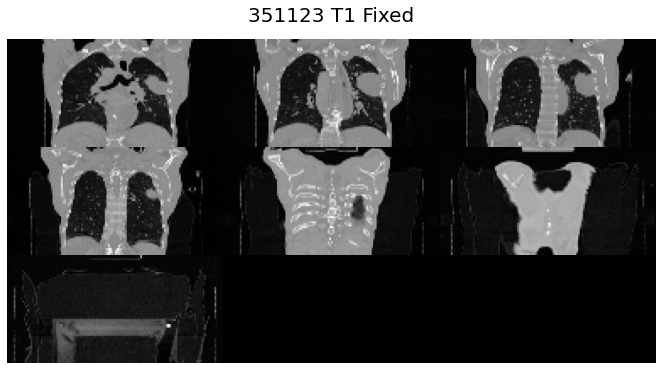

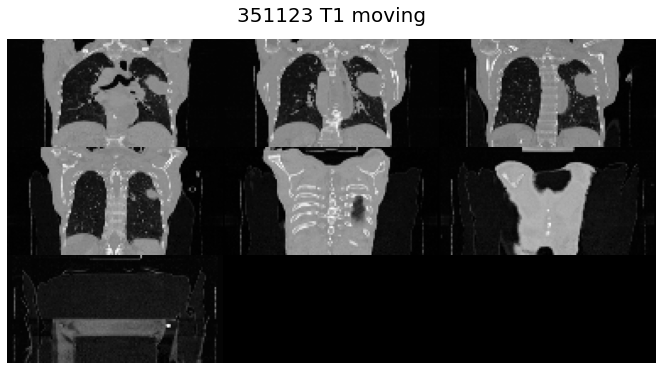

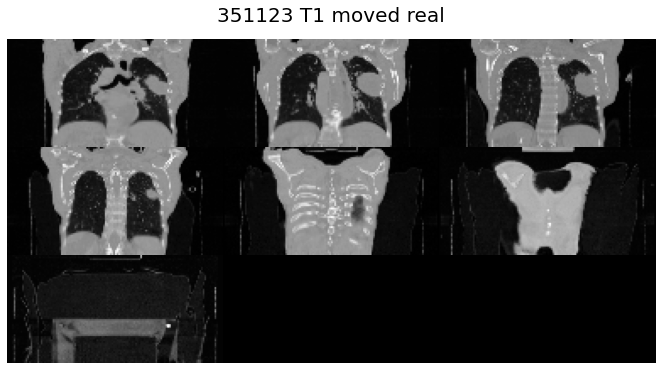

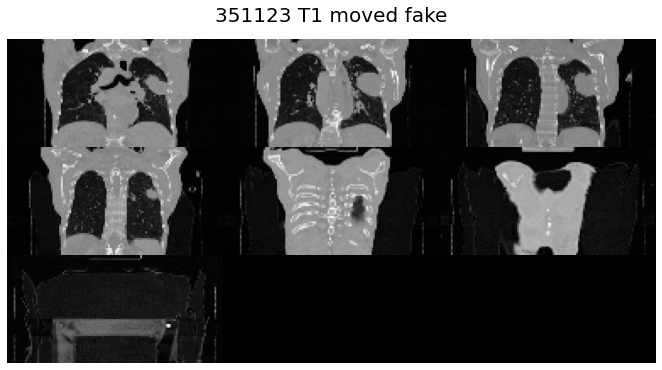

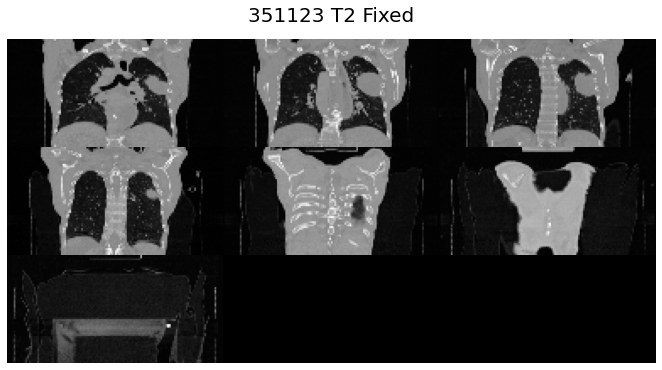

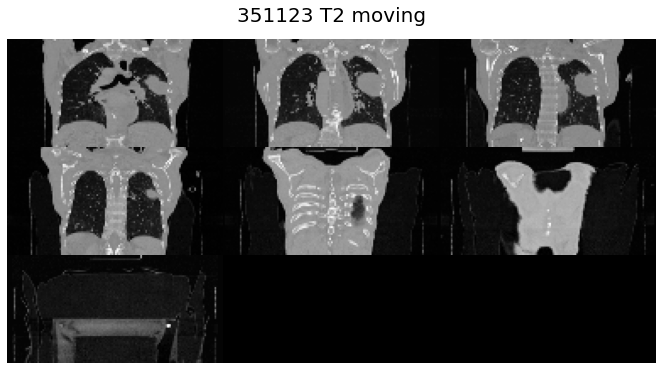

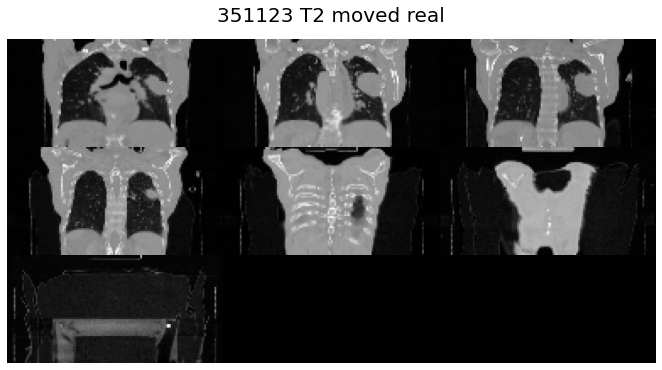

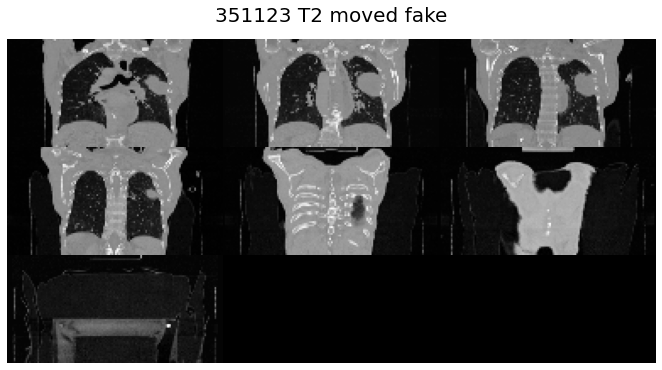

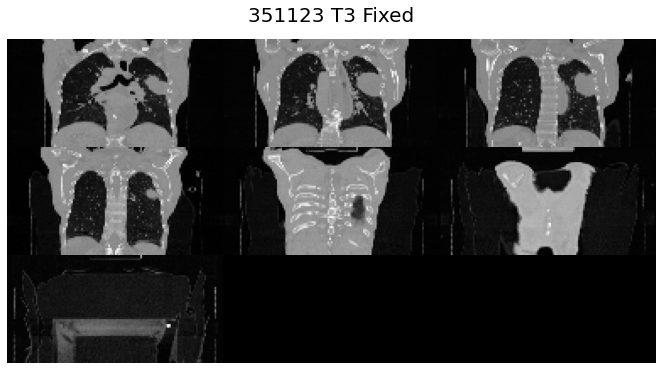

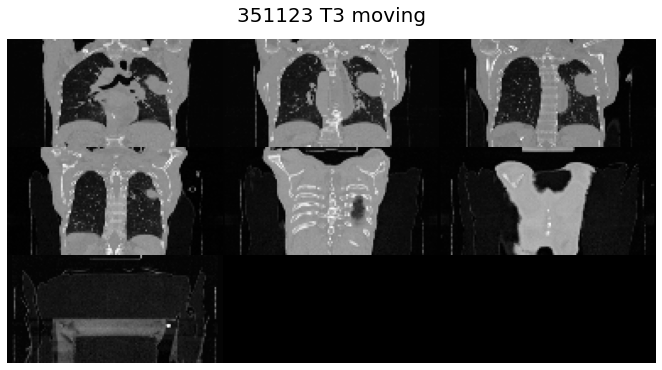

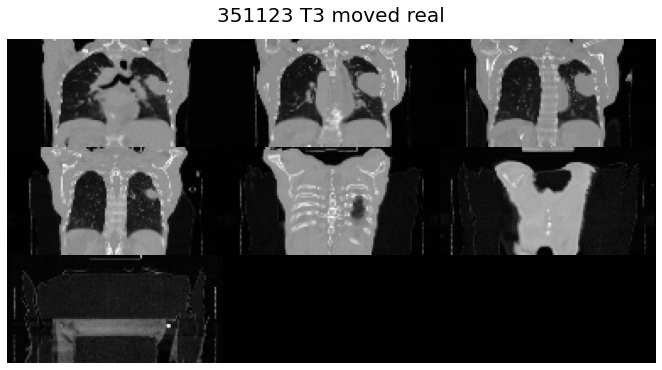

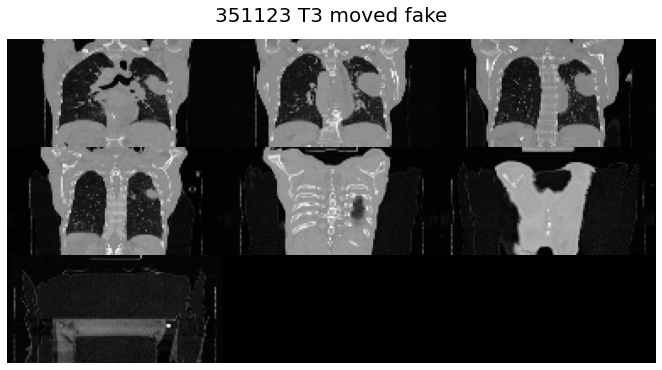

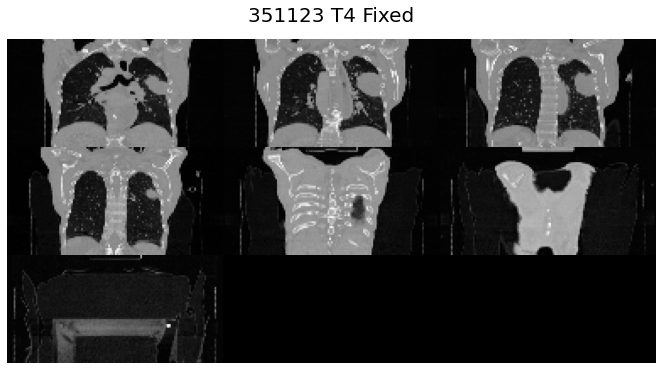

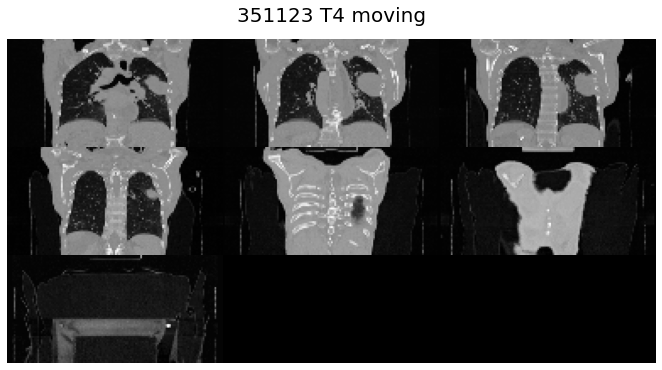

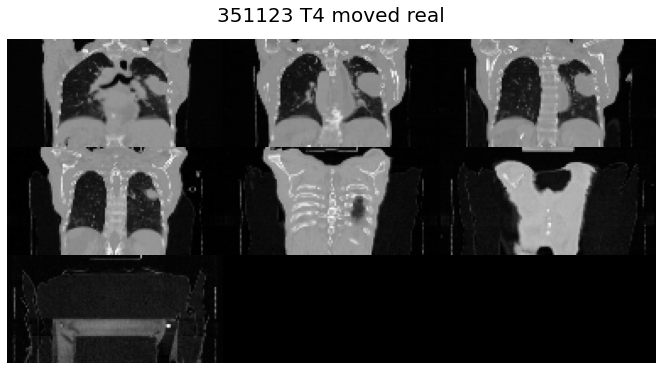

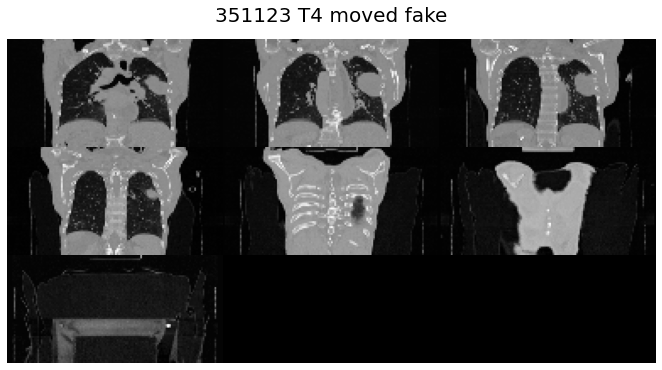

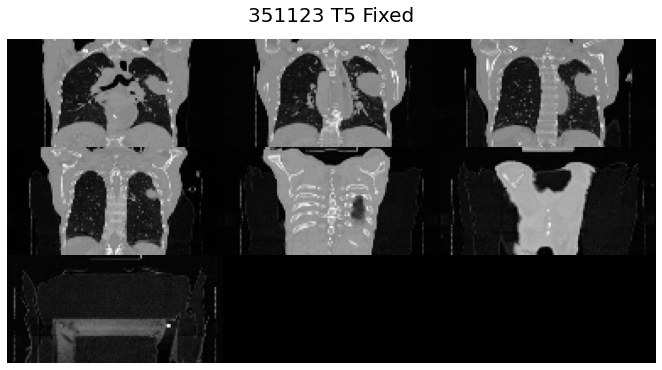

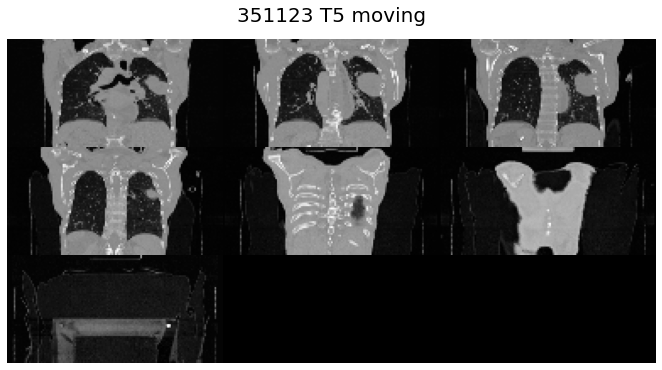

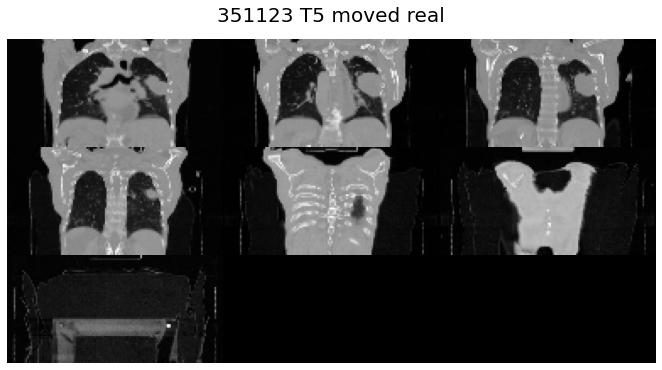

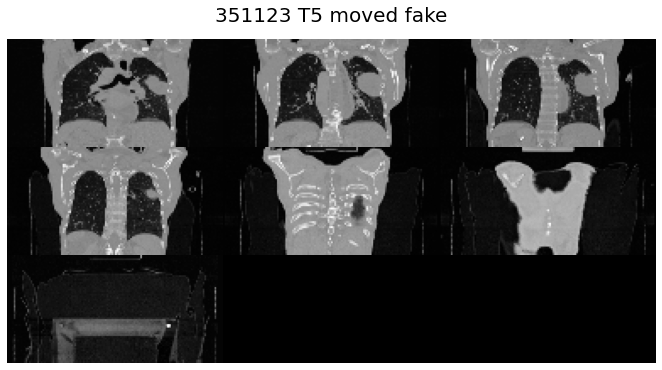

  0%|          | 0/20 [01:13<?, ?it/s]


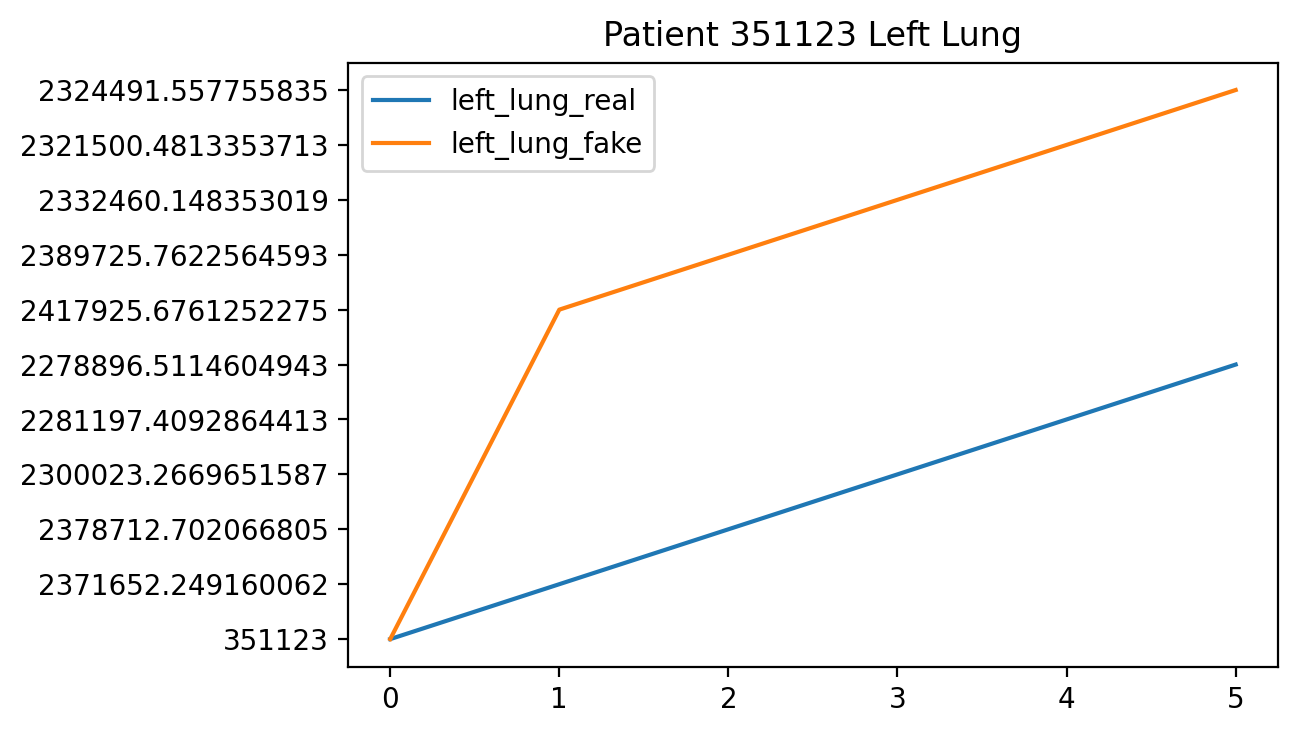

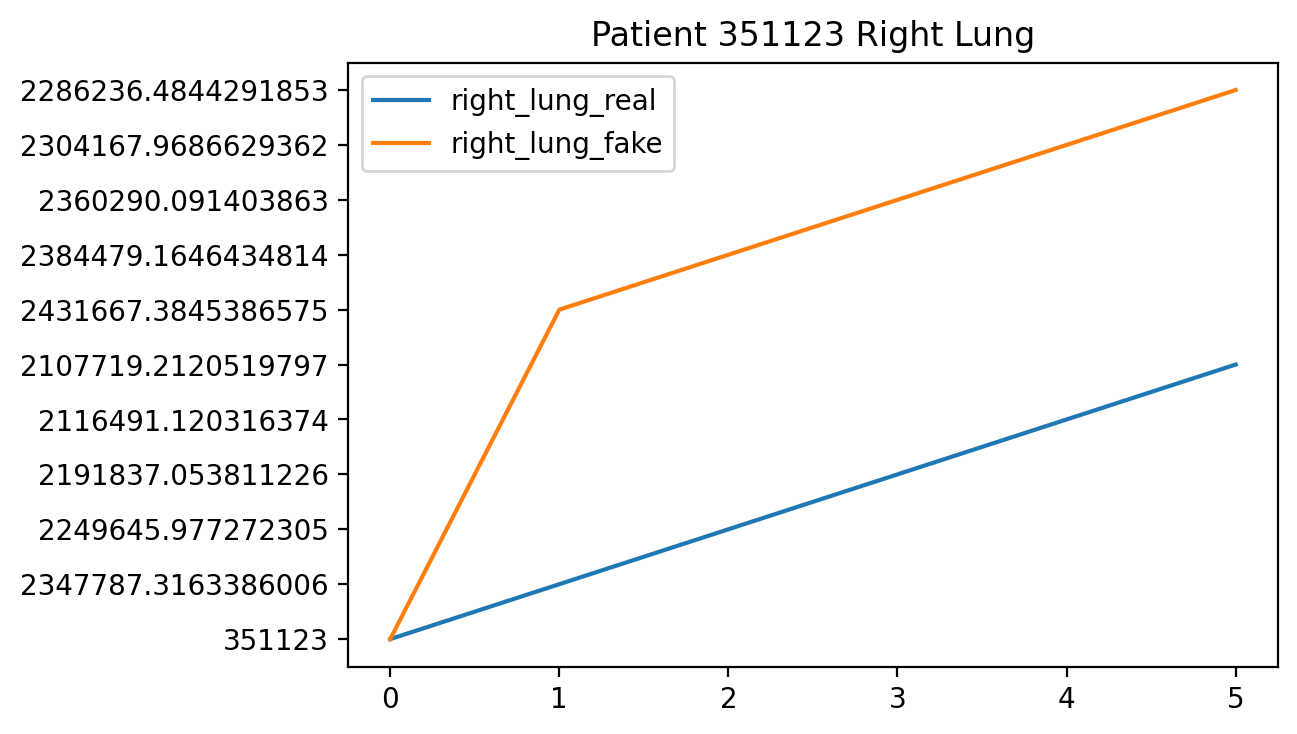

In [2]:
ddf_path = "/home/zhaosheng/paper4/outputs/A2B/99/ddfs"
lung_png_path = "./"
img_save_path = "./"

files = sorted([os.path.join(ddf_path,file) for file in os.listdir(ddf_path) if ".npy" in file])
pnames = set([file.split("/")[-1].split("_")[1] for file in files])

print(pnames)
p_index = 1
left_lung_fake_all,right_lung_fake_all = [],[]
left_lung_real_all,right_lung_real_all = [],[]

for pname in tqdm(pnames):
    logging.info(f"#Start: No.{p_index} {pname}")
    left_lung_real = [pname]
    left_lung_fake = [pname]
    right_lung_real = [pname]
    right_lung_fake = [pname]
    

    # [pname,left_lung_0,left_lung_1, ... ,left_lung_9] -> left_lung
    # [pname,right_lung_0,right_lung_1, ... ,right_lung_9] -> right_lung
    for index in range(1,6):
        fixed = f"/dataset1/4dct_0510/resampled/{pname}_t{index}_resampled.nii"
        moving = f"/dataset1/4dct_0510/resampled/{pname}_t0_resampled.nii"
        real_ddf = os.path.join("/dataset1/4dct_0510/transform",f"{pname}_t{index}_Warp.nii.gz")
        fake_ddf = os.path.join(ddf_path,f"99_{pname}_ddf{index}.npy")
        logging.info(f"\t\tT{index} fixed : {fixed}")
        logging.info(f"\t\tT{index} moving: {moving}")
        logging.info(f"\t\tT{index} ddf_r : {real_ddf}")
        logging.info(f"\t\tT{index} ddf_f : {fake_ddf}")
        
        result = get_result(
            ddf_real=real_ddf,
            ddf_fake=fake_ddf,
            moving=moving,
            fixed=fixed,
            t_index=index,
            savepath=img_save_path,
            plot=True,
        )

        left_lung_real.append(result["lung_real"]["left_lung_volume"])
        left_lung_fake.append(result["lung_fake"]["left_lung_volume"])
        right_lung_real.append(result["lung_real"]["right_lung_volume"])
        right_lung_fake.append(result["lung_fake"]["right_lung_volume"])
        p_index += 1

    plt.figure(dpi=200)
    plt.title(f"Patient {pname} Left Lung")
    plt.plot(left_lung_real,label="left_lung_real")
    plt.plot(left_lung_fake,label="left_lung_fake")
    plt.legend()
    plt.savefig(os.path.join(lung_png_path,f"./{pname}_left_lung.png"))
    # plt.show()

    plt.figure(dpi=200)
    plt.title(f"Patient {pname} Right Lung")
    plt.plot(right_lung_real,label="right_lung_real")
    plt.plot(right_lung_fake,label="right_lung_fake")
    plt.legend()
    plt.savefig(os.path.join(lung_png_path,f"./{pname}_right_lung.png"))
    # plt.show()
    
    left_lung_real_all.append(left_lung_real)
    logging.info(f"\tLeft Lung Real: {left_lung_real}")
    left_lung_fake_all.append(left_lung_fake)
    logging.info(f"\t\tLeft Lung Fake: {left_lung_fake}")
    right_lung_real_all.append(right_lung_real)
    logging.info(f"\t\tRight Lung Real: {right_lung_real}")
    right_lung_fake_all.append(right_lung_fake)
    logging.info(f"\t\tRight Lung Fake: {right_lung_fake}")

    break


In [3]:
a = np.load("/home/zhaosheng/paper4/outputs/A2B/99/ddfs/99_346699_ddf5.npy")

In [16]:
img_fake = ants.image_read("/dataset1/4dct_0510/transform/356857_t5_Warp.nii.gz")
print(img_fake.shape)
print(img_fake.spacing)
img_real = ants.image_read("/home/zhaosheng/paper4/ipynb/temp.nii.gz")
print(img_real.shape)
print(img_real.spacing)

npy = ants.image_read("/home/zhaosheng/paper4/ipynb/temp.nii.gz").numpy().transpose(1,2,3,0)
# test = ants.from_numpy(npy)
# test = ants.resample_image_to_target(test,img_fake)

# print(test.spacing)
# print(test.shape)

img_fake[:,:,:,:] = npy[:,:,:,:]
print(img_fake.spacing)

(128, 128, 64)
(3.929318428039551, 3.929318428039551, 3.809523820877075)
(128, 128, 64, 3)
(3.929318428039551, 3.929318428039551, 3.809523820877075, 1.0)


/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



ValueError: could not broadcast input array from shape (128,64,3,128) into shape (3,128,128,64)

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



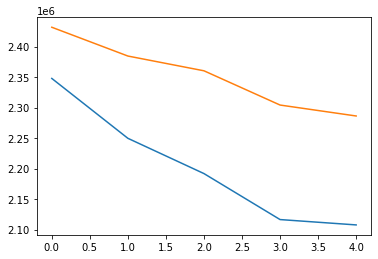

In [5]:
plt.plot([2347787.3163386006, 2249645.977272305, 2191837.053811226, 2116491.120316374, 2107719.2120519797],label="real right")
plt.plot([2431667.3845386575, 2384479.1646434814, 2360290.091403863, 2304167.9686629362, 2286236.4844291853],label="fake right")


(128, 128, 64, 3)


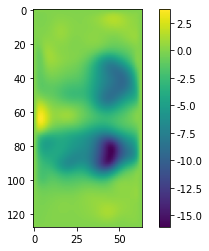

In [10]:
ddf_real = ants.image_read("/dataset1/4dct_0510/transform/356857_t5_Warp.nii.gz").numpy()
# ddf_real += 1000
print(ddf_real.shape)
plt.imshow(ddf_real[:,64,:,2])
plt.colorbar()
# ddf_real.plot()

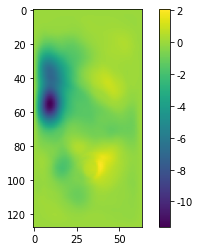

In [16]:
plt.imshow(img[2,:,55,:])
plt.colorbar()